# Temperature at the Tap

## Learning Objectives

- Read the undisturbed soil temperature at pipe depth off a surface weather record, and see how
  depth damps the swing and delays it
- Separate the classical one-way relaxation from the two-way correction the pipe's own heat makes
  to the soil around it
- See why the wall heat has to be booked over the time water actually spends in a pipe, and what
  that changes for a branch that stands still overnight
- Watch the water and the soil take turns until the two-way answer stops moving, and read how
  fast each round shrinks
- Reconstruct the produced temperature from tap measurements, and read the model's own statement
  of which bins it will not answer

## Theoretical background

### Relaxation toward a moving target

A parcel of water in a buried pipe obeys Newton's law of cooling toward the temperature of the
soil around it,

$$\frac{dT}{dt} = -h\,\bigl(T - T_b(t)\bigr),$$

with $h$ [1/day] the exchange rate: the series resistance of the water-side film, the pipe wall
and the soil, divided by the heat capacity of the water column. This is first-order decay toward
a *moving target* instead of toward zero, so the delivered temperature is an **affine** reading of
the same transport operator the rest of the package uses,

$$T_\mathrm{out} = W\,T_\mathrm{in} + b,$$

with $W$ built with $h$ in the decay-rate slot and $b$ the soil's contribution accumulated along
each path. Everything below is a way of asking what $T_b$ is.

### The soil is not a boundary condition, it is a memory

If the pipe were a passive thermometer, $T_b$ would be the *undisturbed* soil temperature at pipe
depth — the half-space response to the weather at the surface. That is the classical one-way
model, and `max_sweeps=1` returns exactly it.

But a pipe that has been losing heat for a week has warmed the ground around it, and it then
exchanges against that warmer halo rather than against undisturbed soil. Splitting the wall's
response into a **steady part plus a transient deficit** turns the two-way problem back into the
one-way problem with a shifted target,

$$T_{b,e}[n] = T_\infty[n] - \sum_{j \le n} \Delta\psi_e[j]\,\bar{D}[n-j],$$

a convolution of the segment's own wall-flux history $\psi$ against the soil's deficit response.
The flux is not one number per pipe per bin: each pipe carries its wall flux as `n_modes` axial
Legendre modes — six by default — where mode 0 is the pipe-average flux and the higher modes
resolve how it varies along the pipe, inlet to outlet. Each mode drives its own convolution and
shifts its own component of the target, so the halo can be thicker where the water runs hottest
without the pipe being cut into pieces.

### Two systems, taking turns

There are two systems here with very different clocks. The **water system** is fast: parcels
cross the network in hours, and given a target series per pipe, the delivered temperature is one
pass of the affine operator above. The **soil system** is slow: each pipe's halo integrates the
wall flux over weeks. The only thing they exchange is the wall flux itself — the water pass
determines it, the soil pass turns its history into shifted targets.

The model alternates the two passes — a **Picard iteration** on the targets. Start by assuming
undisturbed ground and route the water (that first pass *is* the classical one-way model). Read
off each pipe's mode-resolved enthalpy budget, let the soil respond, and route the water again
against the shifted targets. Each round moves the targets less than the one before, because a
pipe only takes its water a fraction $h\tau$ of the way to its target, so only that fraction of a
target shift comes back as a changed flux. The iteration stops when a full round moves no target
by more than `atol`; `max_sweeps` caps the number of rounds. (The package accelerates the
iteration numerically, but this alternation is the picture.) Where the geometry cannot contract —
a pipe flushed several volumes inside a single bin asks for modes the bin width cannot drive —
the model refuses and names the segment rather than iterating anyway.

### Where the heat is booked

The flux $\psi$ of a bin is the segment's own **enthalpy budget** over that bin: what it advected
in, minus what it advected out, minus the change in what it is holding. That matters most where
it is least obvious. Water standing in a pipe overnight exchanges heat for as long as it stands,
and a bin with no throughflow still leaks $-h(H - V T_b)$ into the soil. Charging that heat
instead to the single bin the water finally leaves in would overstate that bin by the ratio of
the standing time to the transit — which is the difference between a model that settles when you
refine it and one that does not.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pipetransport import plot
from pipetransport.examples import example_demand, example_network
from pipetransport.heat import (
    HeatNetwork,
    endmember_to_source,
    segment_heat_rate,
    soil_temperature,
    sol_air_temperature,
    source_to_endmember,
)

# Soil per land cover, which is how a utility usually knows it; the network below carries it
# per segment, because two pipes may share a cover and still sit in different ground.
SOIL = {
    "grass": {"alpha": 0.05, "kappa_soil": 0.025},
    "paved": {"alpha": 0.07, "kappa_soil": 0.035},
}


def sol_air(air, sun, *, absorptivity, latent):
    """Sol-air temperature: air, plus absorbed sunlight, less longwave and evaporation.

    ``sun`` is in W/m²; the 0.0207 converts W/m² to the package's K·m/day. The longwave term
    is a net 30 W/m² and the latent term is a fraction of the sunshine, which is the greater
    part of why grass runs cooler than pavement.
    """
    return sol_air_temperature(
        air_temperature=air,
        solar_irradiance=sun * 0.0207,
        absorptivity=absorptivity,
        eta=0.41,
        heat_loss=(30.0 + latent * sun) * 0.0207,
    )

## 1. The network and what it is buried under

The same seven-segment example network the water-quality notebook uses, wrapped in a `HeatNetwork`:
the subclass that carries everything constant in time — land cover, burial depth and the soil the
pipe sits in — one row per segment, validated when the network is built rather than when it is
solved. Pavement is given both a higher diffusivity and a higher conductivity than grass.

Soil is per *segment*, not per cover class, so two pipes may share a cover and still sit in
different ground; `cover` is left one job, keying the surface forcing below. The wall and film
columns are omitted here, which is exactly a bare pipe.

In [2]:
buried = {  # land cover and burial depth of each pipe
    "Plant-A": ("grass", 1.2),
    "A-B": ("grass", 1.0),
    "A-C": ("paved", 1.0),
    "B-T1": ("paved", 0.9),
    "B-T2": ("grass", 1.0),
    "C-T3": ("paved", 1.0),
    "C-T4": ("grass", 0.8),
}
# Each pipe's properties travel together: geometry from the transport network, plus the ground
# it sits in. eta is the surface film; inf would be a prescribed-temperature surface.
pipes = example_network().segments.drop(columns="volume").to_dict(orient="index")
network = HeatNetwork(
    segments={
        name: {**pipe, "cover": cover, "depth": depth, **SOIL[cover], "eta": 0.41}
        for name, pipe in pipes.items()
        for cover, depth in [buried[name]]
    },
    source="Plant",
)
segments = network.segments  # the validated table, with volume derived and defaults filled

print(segments[["length", "diameter", "volume", "cover", "depth", "alpha", "kappa_soil"]].round(3))

         length  diameter   volume  cover  depth  alpha  kappa_soil
Plant-A  2000.0      0.40  251.327  grass    1.2   0.05       0.025
A-B      1500.0      0.30  106.029  grass    1.0   0.05       0.025
A-C      1200.0      0.25   58.905  paved    1.0   0.07       0.035
B-T1      800.0      0.15   14.137  paved    0.9   0.07       0.035
B-T2      400.0      0.20   12.566  grass    1.0   0.05       0.025
C-T3      600.0      0.15   10.603  paved    1.0   0.07       0.035
C-T4     2500.0      0.10   19.635  grass    0.8   0.05       0.025


## 2. From the weather to the soil at pipe depth

The undisturbed field is the superposition of Robin-boundary step responses of the half space,
driven by the sol-air temperature — the air temperature plus the absorbed sunlight, less what the
surface loses to the sky and to evaporation.

At pipe depth the diurnal signal is essentially gone: the damping depth $\sqrt{\alpha P/\pi}$ is
about 0.13 m for grass at a one-day period, so a metre of soil damps the daily swing by $e^{-7.9}$.
What survives is the *seasonal* wave, damped and delayed. Two years of daily weather, the second
read at three depths:

In [3]:
year_tedges = pd.date_range("2023-06-15", "2025-06-15", freq="D")
day = np.arange(len(year_tedges) - 1)
season = 10.5 + 8.5 * np.sin(2 * np.pi * (day - 45 + 91.25) / 365.0)  # air peaks end of July
sun = 300.0 * np.clip(np.sin(2 * np.pi * (day - 6 + 91.25) / 365.0), 0.0, None)  # daily mean W/m2

year_surface = {
    "grass": sol_air(season, sun, absorptivity=0.25, latent=0.35),
    "paved": sol_air(season, sun, absorptivity=0.90, latent=0.0),
}

settled = slice(365, None)  # drop the first year: the soil starts undisturbed and has to warm up
rows, fields = [], {}
for cover, alpha in (("grass", 0.05), ("paved", 0.07)):
    for depth in (0.5, 1.0, 2.0):
        field = soil_temperature(
            surface_temperature=year_surface[cover],
            tedges=year_tedges,
            depth=depth,
            alpha=alpha,
            radiation_length=SOIL[cover]["kappa_soil"] / 0.41,
        )
        fields[cover, depth] = field
        rows.append({
            "cover": cover,
            "depth [m]": depth,
            "mean [C]": field[settled].mean(),
            "swing [K]": field[settled].max() - field[settled].min(),
            "lag [days]": int(np.argmax(field[settled])) - int(np.argmax(year_surface[cover][settled])),
        })

print(f"sol-air annual mean [C]: { {c: round(float(v.mean()), 2) for c, v in year_surface.items()} }")
print(f"sol-air annual swing [K]: { {c: round(float(np.ptp(v)), 1) for c, v in year_surface.items()} }")
print()
print(pd.DataFrame(rows).round(2).to_string(index=False))

sol-air annual mean [C]: {'grass': 8.51, 'paved': 13.35}
sol-air annual swing [K]: {'grass': 15.9, 'paved': 29.5}

cover  depth [m]  mean [C]  swing [K]  lag [days]
grass        0.5      8.84      12.64          14
grass        1.0      9.12      10.34          26
grass        2.0      9.68       6.95          49
paved        0.5     14.19      24.25          11
paved        1.0     14.90      20.59          20
paved        2.0     16.30      14.96          39


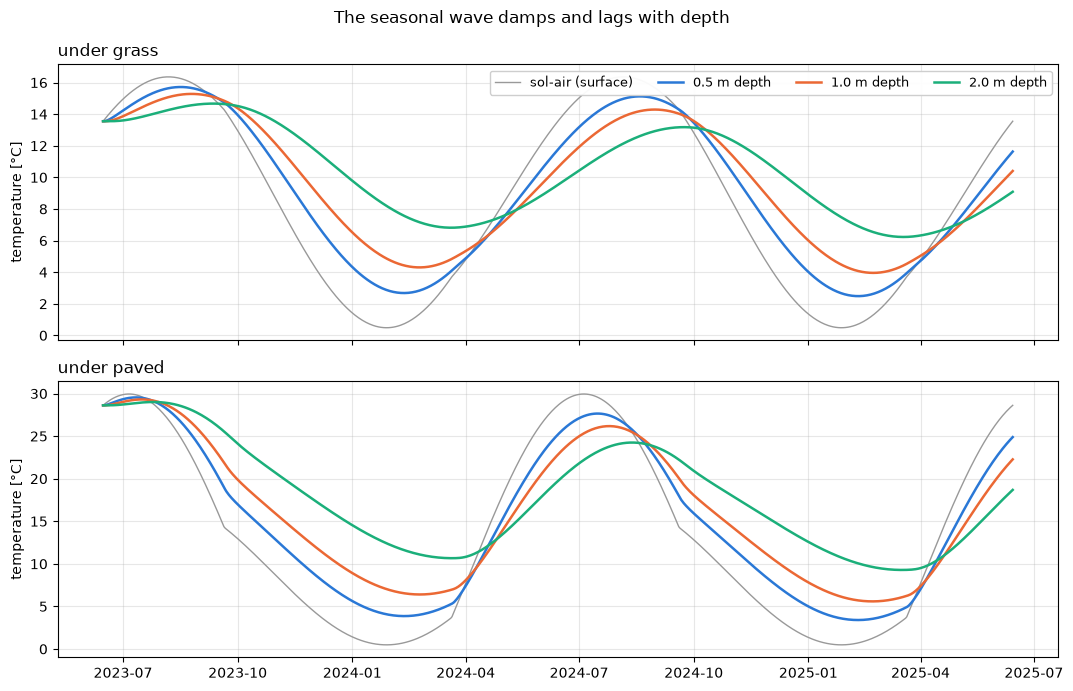

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
days = year_tedges[:-1]
for ax, cover in zip(axes, ("grass", "paved"), strict=True):
    ax.plot(days, year_surface[cover], color="0.6", lw=1.0, label="sol-air (surface)")
    for depth, color in zip((0.5, 1.0, 2.0), plot.series_colors(3), strict=True):
        ax.plot(days, fields[cover, depth], color=color, lw=1.8, label=f"{depth:.1f} m depth")
    ax.set_ylabel("temperature [°C]")
    ax.set_title(f"under {cover}", loc="left")
    ax.grid(alpha=0.3)
axes[0].legend(loc="upper right", ncol=4, fontsize=9, framealpha=0.95)
axes[1].set_xlabel("")
fig.suptitle("The seasonal wave damps and lags with depth", y=0.98)
fig.tight_layout()

Deeper is flatter and later, and the two covers differ by more than their surfaces do only
because pavement conducts better as well as absorbing more. The first year is discarded on
purpose: the model starts the soil undisturbed, and at a metre that assumption takes a season to
pay off — which is the same reason the network run below opens its record three weeks before the
window of interest.

## 3. What arrives at the taps

Every input lives on one `tedges` grid, so warming the model up means *starting the grid early*.
Three weeks — the $d_\mathrm{eff}^2/\alpha$ over which the halo kernel decays — is what the
network's own halo needs: without it the model opens onto undisturbed soil, as if every pipe had
been laid that morning. The output grid is free, so `cout_tedges` covers the fortnight of interest
and nothing has to be discarded afterwards. (The third memory, the water standing in the pipes, is
the automatic `spinup`.)

Three weeks does *not* settle the soil field itself. At a metre only about half of any surface
change has arrived by then, and the rest still leans on the record's first value — which is why
section 2 needed two years to show the seasonal wave. Read the halo *correction* below rather than
the absolute delivered temperature, and give a real study a record that reaches back seasons.

`max_sweeps=1` is the classical one-way model; the default is the two-way fixed point, and the
difference between them is the halo the network has built in its own soil. After the plot, the same
run is repeated at looser tolerances to show how the iteration closes in on the fixed point.

In [5]:
lead_in = 21  # days: d_eff^2 / alpha, the span over which the halo kernel decays
tedges = pd.date_range("2025-05-11", periods=(lead_in + 14) * 24 + 1, freq="h")
cout_tedges = tedges[lead_in * 24 :]  # report on the fortnight of interest, 1-15 June
sh = np.arange(len(tedges) - 1)
doy = sh / 24.0 - (lead_in + 14)  # days from 15 June, so the seasonal term matches section 2
air = 10.5 + 8.5 * np.sin(2 * np.pi * (doy - 45 + 91.25) / 365.0) + 5.0 * np.sin(2 * np.pi * (sh - 9) / 24.0)
noon = 800.0 * np.clip(np.sin(2 * np.pi * (sh - 6) / 24.0), 0.0, None)
surface = {
    "grass": sol_air(air, noon, absorptivity=0.25, latent=0.35),
    "paved": sol_air(air, noon, absorptivity=0.90, latent=0.0),
}

hours = np.arange(len(tedges) - 1)
demand = example_demand(tedges=tedges, network=network)

transit = segments["volume"] / network.segment_flow(flow=demand).mean(axis=1)
rate = pd.Series(segment_heat_rate(network=network))
print(
    pd.DataFrame({
        "h [1/day]": rate.round(2),
        "transit [h]": (transit * 24).round(2),
        "h*tau [-]": (rate * transit).round(2),
    }).to_string()
)

         h [1/day]  transit [h]  h*tau [-]
Plant-A       0.49         7.54       0.15
A-B           0.84         4.24       0.15
A-C           1.57         7.07       0.46
B-T1          3.81         1.41       0.22
B-T2          1.64         0.84       0.06
C-T3          3.70         2.12       0.33
C-T4          5.65         5.89       1.39


`h*tau` is the fraction of the way to the soil a pipe takes its water: the trunk main barely
moves it, while the long thin branch to T4 nearly equilibrates. Thin pipes lose their water's
temperature for the same reason they lose chlorine — surface per unit volume.

In [6]:
tin = 11.0 + 1.5 * np.sin(2 * np.pi * hours / (24 * 7))
NODES = ["T1", "T4"]

# The T2 branch passes 1.7 pipe volumes in a single hourly bin at its peak flow, and axial
# modes finer than the bin width can drive do not converge -- the sweep refuses them by
# name. Four modes are what this network's bin width resolves; the single-pipe ladder in
# section 4 shows the six-mode default where the resolution supports it.
N_MODES = 4

one_way = source_to_endmember(
    tin=tin,
    flow=demand,
    tedges=tedges,
    cout_tedges=cout_tedges,
    network=network,
    surface_temperature=surface,
    report_nodes=NODES,
    max_sweeps=1,  # the classical one-way model: relax toward the undisturbed field
    n_modes=N_MODES,
)
two_way = source_to_endmember(
    tin=tin,
    flow=demand,
    tedges=tedges,
    cout_tedges=cout_tedges,
    network=network,
    surface_temperature=surface,
    report_nodes=NODES,
    n_modes=N_MODES,
)

for node, delivered in two_way.items():
    print(
        f"{node}: produced {tin.min():.1f}-{tin.max():.1f} C, "
        f"delivered {np.nanmin(delivered):.2f}-{np.nanmax(delivered):.2f} C, "
        f"halo correction up to {np.nanmax(np.abs(delivered - one_way[node])):.2f} K"
    )

T1: produced 9.5-12.5 C, delivered 11.15-13.77 C, halo correction up to 1.02 K
T4: produced 9.5-12.5 C, delivered 10.01-11.58 C, halo correction up to 0.81 K


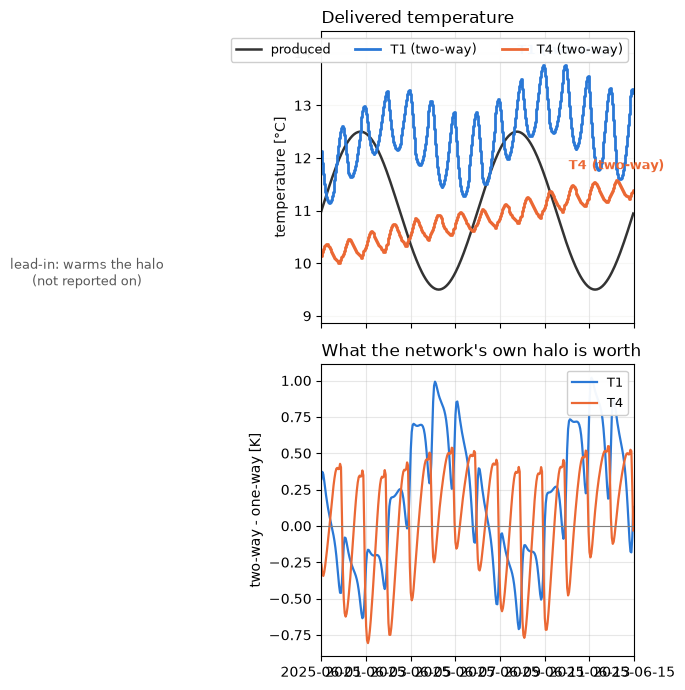

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(tedges[:-1], tin, color="0.2", lw=1.8, label="produced")
plot.endmember_series(
    values={f"{node} (two-way)": series for node, series in two_way.items()},
    tedges=cout_tedges,
    ylabel="temperature [°C]",
    ax=axes[0],
)
axes[0].axvspan(tedges[0], cout_tedges[0], color="0.92", zorder=0)
axes[0].text(
    tedges[lead_in * 12],
    tin.min(),
    "lead-in: warms the halo\n(not reported on)",
    va="bottom",
    ha="center",
    fontsize=9,
    color="0.35",
)
axes[0].set_title("Delivered temperature", loc="left")
axes[0].legend(loc="upper right", ncol=3, fontsize=9, framealpha=0.95)
axes[0].grid(alpha=0.3)

for node, color in zip(NODES, plot.series_colors(2), strict=True):
    axes[1].plot(cout_tedges[:-1], two_way[node] - one_way[node], color=color, lw=1.6, label=node)
axes[1].axhline(0.0, color="0.5", lw=0.8)
axes[1].set_ylabel("two-way - one-way [K]")
axes[1].set_title("What the network's own halo is worth", loc="left")
axes[1].legend(loc="upper right", fontsize=9, framealpha=0.95)
axes[1].grid(alpha=0.3)
fig.tight_layout()

The correction has a sign, and it is not the one a "the pipe has warmed its surroundings" picture
suggests. The target is an *effective driving temperature*, not a wall temperature: the exchange
rate keeps the fully developed soil resistance, which understates how fast a pipe exchanges while
its halo is still building, so the target has to be pushed *past* the undisturbed soil to make up
the difference. The two-way model therefore moves the delivered temperature further **toward** the
soil than the one-way model does — upward at T1, which is warming under pavement, and downward at
T4, which is cooling under grass.

It is not a small effect on the branch that nearly equilibrates, and it does not average out: it
is a memory, so it depends on what the network was doing for weeks beforehand.

In [8]:
# The iteration stops when a full water-soil round moves no target by more than atol.
# Loosen atol and it stops earlier; the distance to the fixed point shrinks with it.
for atol in (1.0, 0.1, 0.01):
    stopped_early = source_to_endmember(
        tin=tin,
        flow=demand,
        tedges=tedges,
        cout_tedges=cout_tedges,
        network=network,
        surface_temperature=surface,
        report_nodes=NODES,
        atol=atol,
        n_modes=N_MODES,
    )
    left = max(np.nanmax(np.abs(two_way[node] - stopped_early[node])) for node in NODES)
    print(f"atol = {atol:>4}: delivered answer is within {left:.4f} K of the fixed point")

atol =  1.0: delivered answer is within 0.0045 K of the fixed point


atol =  0.1: delivered answer is within 0.0008 K of the fixed point


atol = 0.01: delivered answer is within 0.0001 K of the fixed point


Each round of the alternation buys roughly the same *fraction* of what is left — the geometric
convergence of a contraction — so stopping at a tolerance a hundred times looser leaves an answer
roughly a hundred times further from the fixed point, and reaching the default `atol=1e-7` costs
only a handful of additional rounds. The fraction is set by the strongest coupling in the
network: a pipe hands back only about $h\tau$ of any target shift as changed flux, and the
tightly coupled T4 branch is what sets the pace here. Asked for more rounds than it is willing to
take (`max_sweeps`), the model raises rather than returning the unconverged iterate.


## 4. Water that stands still

A dead-end branch that draws nothing overnight is where the wall flux has to be booked correctly.
The water in it goes on exchanging heat for the whole idle period, and the model books that heat
into the hours it actually happens in — and into the *positions* it happens at, because each pipe
carries its wall flux in `n_modes` axial Legendre modes, six by default. The test is whether the
answer *settles* as the modes are raised: a model whose refinement diverges cannot be trusted at
any order. One mode is the classical uniform-flux model, and the ladder below is what the higher
modes are worth.

In [9]:
def idle_branch(n_modes, *, days=6, idle_hours=9):
    """Deliver through one 100 mm, 1 km grass line that draws nothing for part of each day."""
    net = HeatNetwork(
        segments={
            "s0": {
                "from": "Plant",
                "to": "T1",
                "length": 1000.0,
                "diameter": 0.1,
                "cover": "grass",
                **SOIL["grass"],
                "eta": 0.41,
            }
        },
        source="Plant",
    )
    n = 24 * days
    te = pd.date_range("2025-06-01", periods=n + 1, freq="h")
    volume = float(net.segments["volume"].sum())
    duty = np.concatenate([np.zeros(idle_hours), np.full(24 - idle_hours, volume / (2.0 / 24.0))])
    delivered = source_to_endmember(
        tin=np.full(n, 8.0),
        flow={"T1": np.tile(duty, days)},
        tedges=te,
        cout_tedges=te,
        network=net,
        surface_temperature={"grass": np.full(n, 20.0)},
        n_modes=n_modes,
    )["T1"]
    return delivered, te


runs = {n_modes: idle_branch(n_modes) for n_modes in (1, 2, 6)}
for n_modes, (delivered, _) in runs.items():
    excursion = (np.nanmax(delivered) - 20.0) / 12.0
    print(
        f"at {n_modes} mode(s): delivered max {np.nanmax(delivered):5.2f} C "
        f"({excursion:+6.1%} of the 8→20 C contrast past the soil)"
    )

at 1 mode(s): delivered max 23.26 C (+27.2% of the 8→20 C contrast past the soil)
at 2 mode(s): delivered max 21.01 C ( +8.4% of the 8→20 C contrast past the soil)
at 6 mode(s): delivered max 20.11 C ( +0.9% of the 8→20 C contrast past the soil)


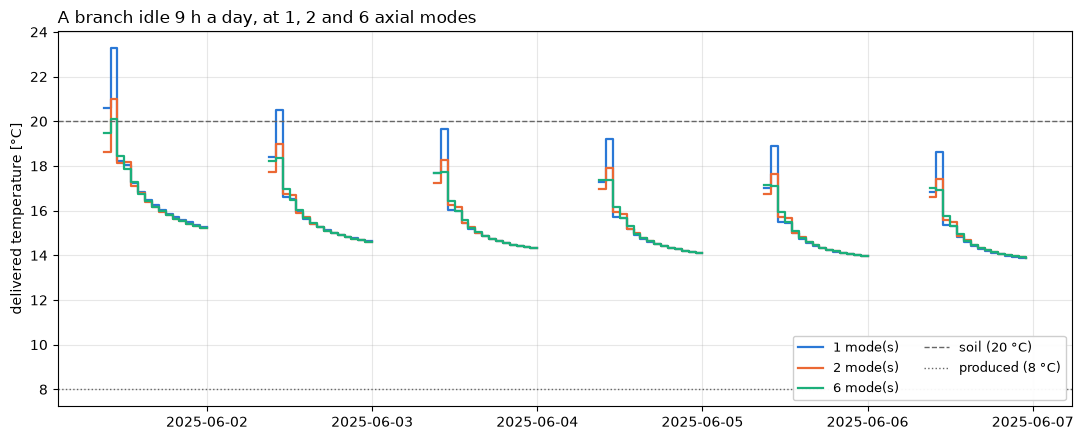

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for (n_modes, (delivered, te)), color in zip(runs.items(), plot.series_colors(3), strict=True):
    ax.step(te[:-1], delivered, where="post", color=color, lw=1.6, label=f"{n_modes} mode(s)")
ax.axhline(20.0, color="0.4", ls="--", lw=1.0, label="soil (20 °C)")
ax.axhline(8.0, color="0.4", ls=":", lw=1.0, label="produced (8 °C)")
ax.set_ylabel("delivered temperature [°C]")
ax.set_title("A branch idle 9 h a day, at 1, 2 and 6 axial modes", loc="left")
ax.legend(loc="lower right", ncol=2, fontsize=9, framealpha=0.95)
ax.grid(alpha=0.3)
fig.tight_layout()

The first flush of the morning is the warmest water of the day — it has been sitting in the
ground all night — and raising the modes moves the answer *down* toward the range of its own
inputs: from a quarter of the water–soil contrast past the soil at one mode, through 8 % at two,
to under 1 % at the six-mode default. What excursion remains is a real property of the model
rather than a bug: the relaxation target is an *effective driving temperature*, and while the
halo is still developing it has to run past the undisturbed soil to reproduce the faster early
exchange. Only `max_sweeps=1` is guaranteed to stay inside the hull of its inputs — and
declaring the pipe as shorter pieces buys nothing the modes do not already resolve.

## 5. What left the plant

The whole model is linear in the produced temperature and the surface temperatures, so the
reverse problem is a deconvolution of the same affine operator. Feeding the delivered
temperatures back in should return the production series they came from.

The interesting part is what the answer leaves out. Bins the record does not constrain come back
`NaN`, and so do bins whose reconstruction leans on flux the model had to invent — over a sensor
outage, or past the end of the record, where most of the heat the last bins exchange arrives
after the measurements stop.

One caveat before feeding anything back: the two-way reverse is well-posed only while every
segment's coupling stays inside the `h·τ` boundary the `endmember_to_source` notes describe, and
in the soil above the T4 service line sits past it. The demonstration therefore runs both
directions on a lighter, drier soil — and at two axial modes, since the deconvolution does not
depend on the mode count.

In [11]:
# A lighter soil keeps every segment's h*tau inside the boundary the reverse can invert.
light = HeatNetwork(
    segments=segments.drop(columns="volume").assign(kappa_soil=segments["kappa_soil"] * 0.6),
    source="Plant",
)
# The forward and reverse calls share every argument except the temperature they are given.
measured = source_to_endmember(
    tin=tin,
    flow=demand,
    tedges=tedges,
    cout_tedges=tedges,
    network=light,
    surface_temperature=surface,
    report_nodes=NODES,
    n_modes=2,
)
recovered = endmember_to_source(
    tout=measured,  # the keys already say which taps carry a sensor
    flow=demand,
    tedges=tedges,
    cout_tedges=tedges,
    network=light,
    surface_temperature=surface,
    n_modes=2,
)
answered = np.isfinite(recovered)
last_answered = int(np.max(np.flatnonzero(answered)))
interior = slice(36, last_answered + 1)

print(f"answered {answered.sum()} of {len(recovered)} bins; declined the last {(~answered).sum()}")
print(
    "max |recovered - produced| over the answered bins after the lead-in: "
    f"{np.nanmax(np.abs(recovered[interior] - tin[interior])):.2e} K"
)

answered 802 of 840 bins; declined the last 38
max |recovered - produced| over the answered bins after the lead-in: 5.91e-06 K


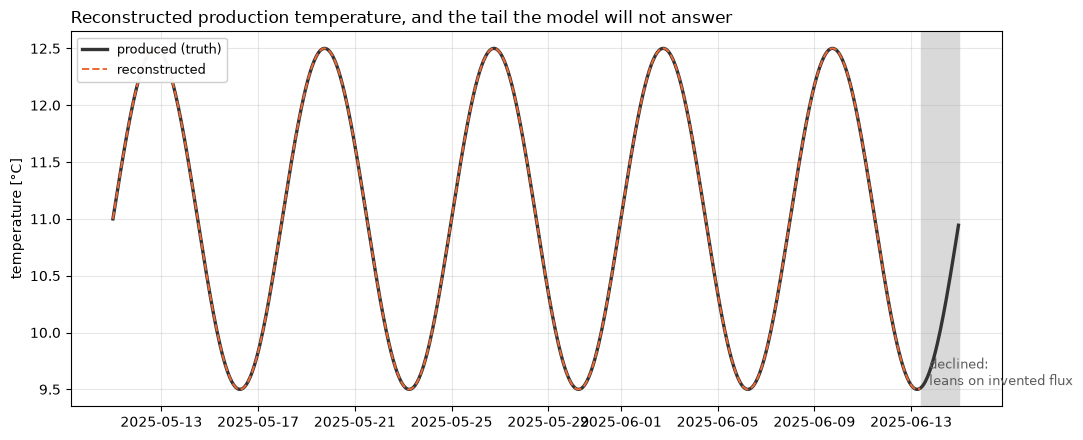

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(tedges[:-1], tin, color="0.2", lw=2.4, label="produced (truth)")
ax.plot(tedges[:-1], recovered, color=plot.series_colors(2)[1], lw=1.4, ls="--", label="reconstructed")
ax.axvspan(tedges[last_answered + 1], tedges[-1], color="0.85", zorder=0)
ax.text(
    tedges[last_answered + 1],
    tin.min(),
    "  declined:\n  leans on invented flux",
    va="bottom",
    ha="left",
    fontsize=9,
    color="0.35",
)
ax.set_ylabel("temperature [°C]")
ax.set_title("Reconstructed production temperature, and the tail the model will not answer", loc="left")
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
ax.grid(alpha=0.3)
fig.tight_layout()

Over the interior the reconstruction is exact to the solver's own tolerance. Toward the end it is
not merely less accurate — it is *unconstrained*, and the model says so instead of returning a
confident number. That is the same mechanism that flags a measurement outage: re-solve without
the invented flux, and any bin whose answer moves is one the record does not support.

## Where to go next

- `pipetransport.heat` — the module docstring states the validity limits and what has been
  measured against them
- The user guide's *Assumptions* page — the axial mode resolution, the effective driving
  target, and what each costs, with measured numbers
- `03_Heat_Exchange_Conceptual_Model.ipynb` — the same physics in pictures, with no equations